In [1]:
! pip install openai --quiet

In [2]:
# Cell 1: Setup & Imports

import os
import json
import random
import time
import math
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
# =====================================
# Ollama Setup
# =====================================

from openai import OpenAI

# Connect to local Ollama server
client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama"   # Can be any string
)

# Name of the model installed in Ollama
MODEL = "qwen2.5:3b"
# Examples:
# MODEL = "qwen2.5:7b"
# MODEL = "deepseek-r1:8b"

NUM_ROUNDS = 10
GOSSIP_SUBROUNDS = 3
BASE_THRESHOLD = 30
THRESHOLD_STEP = 3
STARTING_RESOURCES = 100

print(f"✅ Connected to Ollama")
print(f"🤖 Using model: {MODEL}")

def groq_chat(messages, **kwargs):
    """
    Wrapper for local Ollama running on Docker.
    Usage is identical to the Groq wrapper.
    """
    return client.chat.completions.create(
        model=MODEL,
        messages=messages,
        **kwargs
    )

✅ Connected to Ollama
🤖 Using model: qwen2.5:3b


In [3]:
# Cell 2: Analysis helpers
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)


def persona_label(agent):
    return agent.name.split("_", 1)[1] if "_" in agent.name else agent.name


def safe_int_positive(x, fallback):
    try:
        y = int(round(float(x)))
        return y if y > 0 else fallback
    except Exception:
        return fallback


def safe_conf(x, fallback=5):
    try:
        return max(1, min(10, int(round(float(x)))))
    except Exception:
        return fallback


def compute_bid_entropy(bids):
    if len(bids) == 0:
        return 0.0
    arr = np.round(np.array(bids, dtype=float)).astype(int)
    arr = arr[arr >= 0]
    if len(arr) == 0:
        return 0.0
    counts = np.bincount(arr, minlength=max(100, int(arr.max()) + 1))
    return float(entropy(counts + 1e-9))


def format_ring(ring, agents):
    if not ring:
        return "empty"
    names = {a.id: a.name for a in agents}
    start = min(ring.keys())
    order = [start]
    cur = start
    while True:
        nxt = ring.get(cur)
        if nxt is None or nxt in order:
            break
        order.append(nxt)
        cur = nxt
    start_name = names.get(start, f"Agent{start}")
    ring_text = " -> ".join(names.get(i, f"Agent{i}") for i in order)
    return ring_text + " -> " + start_name


def print_table(title, df, max_rows=None):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))
    if df is None or len(df) == 0:
        print("(empty)")
        return
    out = df.head(max_rows) if max_rows else df
    print(out.to_string(index=False))
    if max_rows and len(df) > max_rows:
        print(f"\n... showing {max_rows}/{len(df)} rows")

print("✅ Analysis helpers loaded")

✅ Analysis helpers loaded


In [4]:
# Cell 3: Game Environment (Week 4 core)
@dataclass
class Agent:
    id: int
    name: str
    persona: str
    resources: int = STARTING_RESOURCES
    alive: bool = True
    intended_bid: int = 0
    confidence: int = 5


def threshold_for_round(r: int) -> int:
    return BASE_THRESHOLD + (r - 1) * THRESHOLD_STEP


# Quick sanity check
for r in range(1, 11):
    print(f"  Round {r}: threshold = {threshold_for_round(r)}")

  Round 1: threshold = 30
  Round 2: threshold = 33
  Round 3: threshold = 36
  Round 4: threshold = 39
  Round 5: threshold = 42
  Round 6: threshold = 45
  Round 7: threshold = 48
  Round 8: threshold = 51
  Round 9: threshold = 54
  Round 10: threshold = 57


In [5]:
# Cell 4: Personas
PERSONAS = [
    ("Aggressive",  "You are bold and risk-taking. You bid high to dominate and often exceed the threshold aggressively."),
    ("Cautious",    "You are conservative. You preserve resources and bid low unless you feel threatened by elimination."),
    ("Analytical",  "You study patterns. Base every bid on previous round history, thresholds, and opponent behavior."),
    ("Random",      "You are unpredictable. You vary bids to confuse opponents but stay somewhat near the threshold."),
    ("Cooperative", "You prefer equilibrium. You try to bid near the group average to keep the game stable."),
]


def get_personas(N: int):
    return [PERSONAS[i % len(PERSONAS)] for i in range(N)]


# Test
for i, p in enumerate(get_personas(10)):
    print(f"  Agent {i}: {p[0]}")

  Agent 0: Aggressive
  Agent 1: Cautious
  Agent 2: Analytical
  Agent 3: Random
  Agent 4: Cooperative
  Agent 5: Aggressive
  Agent 6: Cautious
  Agent 7: Analytical
  Agent 8: Random
  Agent 9: Cooperative


In [6]:
# Cell 5: LLM call + JSON parsing
def call_llm(system: str, user: str, max_tokens: int = 200) -> str:
    for attempt in range(3):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {"role": "system", "content": system},
                    {"role": "user", "content": user},
                ],
                temperature=0.7,
                max_tokens=max_tokens,
            )
            return resp.choices[0].message.content
        except Exception as e:
            print(f"  LLM retry {attempt+1}: {e}")
            time.sleep(1.5)
    return ""


def parse_json_safe(text: str, keys: List[str]) -> Optional[dict]:
    if not text:
        return None
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1:
        return None
    try:
        obj = json.loads(text[start:end+1])
        if all(k in obj for k in keys):
            return obj
    except Exception:
        return None
    return None


# Quick LLM test
test_out = call_llm("You are a helpful assistant.", "Say hello in JSON: {\"msg\": \"...\"}")
print(f"LLM test: {test_out}")

LLM test: {
  "msg": "Hello!"
}


In [7]:
# Cell 6: Generate initial intended bid (gossip sub-round 1)
def generate_initial_bid(agent: Agent, round_num: int, threshold: int, history: str) -> Tuple[int, int, str]:
    system = f"You are {agent.name}. {agent.persona} Always output valid JSON only."
    user = (
        f"You are about to bid in round {round_num}. The threshold this round is {threshold}. "
        f"Your current resources are {agent.resources}. The round history so far is: {history}. "
        f"State your intended bid and how confident you are.\n"
        f'Output JSON only:\n'
        f'{{"intended_bid": <integer>, "confidence": <integer 1-10>, "reasoning": "<one sentence>"}}'
    )
    raw = call_llm(system, user)
    parsed = parse_json_safe(raw, ["intended_bid", "confidence"])
    if parsed and isinstance(parsed["intended_bid"], (int, float)) and parsed["intended_bid"] > 0:
        return (
            int(parsed["intended_bid"]),
            max(1, min(10, int(parsed["confidence"]))),
            parsed.get("reasoning", ""),
        )
    print(f"  ⚠️ parse fail initial bid, agent {agent.name}")
    return (threshold, 5, "fallback")

In [8]:
# Cell 7: Gossip update (sub-rounds 2, 3) + deterministic fallback
def gossip_update(agent: Agent, current_bid: int, my_conf: int,
                  neighbor_bid: int, neighbor_conf: int) -> Tuple[int, int, str]:
    system = f"You are {agent.name}. {agent.persona} Always output valid JSON only."
    user = (
        f"You intended to bid {current_bid} with confidence {my_conf}/10. "
        f"Your neighbor bid {neighbor_bid} with confidence {neighbor_conf}/10. "
        f"Reconsider your bid in light of this. Output JSON only, no other text:\n"
        f'{{"updated_bid": <integer>, "confidence": <integer 1-10>, "reasoning": "<one sentence>"}}'
    )
    raw = call_llm(system, user)
    parsed = parse_json_safe(raw, ["updated_bid", "confidence"])
    if parsed and isinstance(parsed["updated_bid"], (int, float)) and parsed["updated_bid"] > 0:
        return (
            int(parsed["updated_bid"]),
            max(1, min(10, int(parsed["confidence"]))),
            parsed.get("reasoning", ""),
        )
    print(f"  ⚠️ parse fail gossip, agent {agent.name} — keeping prev")
    return (current_bid, my_conf, "fallback-keep")


def weighted_update(my_bid, my_conf, neighbor_bid, neighbor_conf):
    total = my_conf + neighbor_conf
    return round((my_bid * my_conf + neighbor_bid * neighbor_conf) / total)

In [9]:
# Cell 8: Ring topology builder
def assign_ring(N: int, seed: int) -> Dict[int, int]:
    rng = random.Random(seed)
    order = list(range(N))
    rng.shuffle(order)
    ring = {}
    for i, aid in enumerate(order):
        ring[aid] = order[(i + 1) % N]
    return ring


# Test
print("Ring for N=5, seed=0:", assign_ring(5, 0))
print("Ring for N=3, seed=42:", assign_ring(3, 42))

Ring for N=5, seed=0: {2: 1, 1: 0, 0: 4, 4: 3, 3: 2}
Ring for N=3, seed=42: {1: 0, 0: 2, 2: 1}


In [10]:
# Cell 8: Ring topology builder
def assign_ring(N: int, seed: int) -> Dict[int, int]:
    rng = random.Random(seed)
    order = list(range(N))
    rng.shuffle(order)
    ring = {}
    for i, aid in enumerate(order):
        ring[aid] = order[(i + 1) % N]
    return ring


# Test
print("Ring for N=5, seed=0:", assign_ring(5, 0))
print("Ring for N=3, seed=42:", assign_ring(3, 42))

Ring for N=5, seed=0: {2: 1, 1: 0, 0: 4, 4: 3, 3: 2}
Ring for N=3, seed=42: {1: 0, 0: 2, 2: 1}


In [11]:
# Cell 9: Round resolver with detailed logging
def resolve_round_logged(agents, bids, threshold):
    outcomes = {}
    alive_agents = [a for a in agents if a.alive and a.id in bids]
    below_threshold = [
        (aid, int(bid)) for aid, bid in bids.items() if int(bid) < threshold
    ]
    eliminated_id = None
    if below_threshold:
        eliminated_id = min(below_threshold, key=lambda x: (x[1], x[0]))[0]

    for a in alive_agents:
        bid = int(bids[a.id])
        resources_before = a.resources
        if bid >= threshold:
            a.resources += bid
            result = "gain"
            resource_delta = bid
        else:
            a.resources -= bid
            result = "loss"
            resource_delta = -bid

        eliminated_this_round = (a.id == eliminated_id)
        if eliminated_this_round:
            a.alive = False
            result = "eliminated"

        outcomes[a.id] = {
            "bid": bid,
            "resources_before": resources_before,
            "resources_after": a.resources,
            "resource_delta": resource_delta,
            "alive_before": True,
            "alive_after": a.alive,
            "result": result,
            "eliminated_this_round": eliminated_this_round,
        }

    return outcomes, eliminated_id

In [12]:
# Cell 10: Full gossip phase for one round with logging
def play_round_with_gossip_logged(agents, round_num, ring, history,
                                   seed=None, N=None, use_llm_gossip=True):
    threshold = threshold_for_round(round_num)
    alive_agents = [a for a in agents if a.alive]
    initial_info = {}
    gossip_rows = []

    # --- Sub-round 0: initial intended bid ---
    for a in alive_agents:
        bid, conf, reasoning = generate_initial_bid(a, round_num, threshold, history)
        bid = safe_int_positive(bid, fallback=threshold)
        conf = safe_conf(conf, fallback=5)
        a.intended_bid = bid
        a.confidence = conf
        initial_info[a.id] = {
            "initial_bid": bid,
            "initial_conf": conf,
            "initial_reasoning": reasoning,
        }
        gossip_rows.append({
            "N": N, "seed": seed, "round": round_num, "subround": 0,
            "phase": "initial_intent",
            "agent_id": a.id, "agent_name": a.name, "persona": persona_label(a),
            "my_bid_before": None, "my_conf_before": None,
            "neighbor_id": ring.get(a.id),
            "neighbor_bid": None, "neighbor_conf": None,
            "updated_bid": bid, "updated_conf": conf,
            "reasoning": reasoning,
        })

    # --- Sub-rounds 1, 2, 3: gossip updates ---
    for subround in range(1, GOSSIP_SUBROUNDS + 1):
        snapshot = {a.id: (a.intended_bid, a.confidence) for a in alive_agents}
        updates = {}

        for a in alive_agents:
            my_bid, my_conf = snapshot[a.id]
            neighbor_id = ring.get(a.id)

            if neighbor_id in snapshot:
                neighbor_bid, neighbor_conf = snapshot[neighbor_id]
                if use_llm_gossip:
                    new_bid, new_conf, reasoning = gossip_update(
                        a, my_bid, my_conf, neighbor_bid, neighbor_conf
                    )
                else:
                    new_bid = weighted_update(my_bid, my_conf, neighbor_bid, neighbor_conf)
                    new_conf = my_conf
                    reasoning = "deterministic weighted fallback"
            else:
                neighbor_bid, neighbor_conf = None, None
                new_bid, new_conf = my_bid, my_conf
                reasoning = "neighbor dead; kept bid"

            new_bid = safe_int_positive(new_bid, fallback=my_bid)
            new_conf = safe_conf(new_conf, fallback=my_conf)
            updates[a.id] = (new_bid, new_conf)

            gossip_rows.append({
                "N": N, "seed": seed, "round": round_num, "subround": subround,
                "phase": "gossip_update",
                "agent_id": a.id, "agent_name": a.name, "persona": persona_label(a),
                "my_bid_before": my_bid, "my_conf_before": my_conf,
                "neighbor_id": neighbor_id,
                "neighbor_bid": neighbor_bid, "neighbor_conf": neighbor_conf,
                "updated_bid": new_bid, "updated_conf": new_conf,
                "reasoning": reasoning,
            })

        for a in alive_agents:
            if a.id in updates:
                a.intended_bid, a.confidence = updates[a.id]

    # --- Final bids + consensus ---
    final_info = {a.id: {"final_bid": a.intended_bid, "final_conf": a.confidence} for a in alive_agents}
    final_bids = {aid: info["final_bid"] for aid, info in final_info.items()}
    consensus = int(round(np.mean(list(final_bids.values())))) if final_bids else 0
    accuracy = 1 if consensus >= threshold else 0

    return {
        "threshold": threshold,
        "initial_info": initial_info,
        "final_info": final_info,
        "final_bids": final_bids,
        "consensus": consensus,
        "accuracy": accuracy,
        "bid_entropy": compute_bid_entropy(list(final_bids.values())),
        "gossip_rows": gossip_rows,
    }

In [13]:
# Cell 11: Full 10-round game with printed results
def run_full_game_logged(N, seed, verbose=True, use_llm_gossip=True):
    random.seed(seed)
    np.random.seed(seed)

    personas = get_personas(N)
    agents = [Agent(id=i, name=f"Agent{i}_{p[0]}", persona=p[1]) for i, p in enumerate(personas)]
    agent_by_id = {a.id: a for a in agents}
    ring = assign_ring(N, seed)

    history_log = []
    round_rows, agent_rows, gossip_rows_all = [], [], []
    consensus_bids, round_accuracies = [], []

    if verbose:
        print("\n" + "#" * 90)
        print(f"GAME START | N={N} | seed={seed}")
        print("#" * 90)
        print(f"\nGossip ring: {format_ring(ring, agents)}")

    for r in range(1, NUM_ROUNDS + 1):
        history_str = "; ".join(history_log[-3:]) if history_log else "none"
        packet = play_round_with_gossip_logged(agents, r, ring, history_str, seed, N, use_llm_gossip)
        threshold = packet["threshold"]
        consensus = packet["consensus"]
        accuracy = packet["accuracy"]

        outcomes, eliminated_id = resolve_round_logged(agents, packet["final_bids"], threshold)
        eliminated_name = agent_by_id[eliminated_id].name if eliminated_id is not None else None
        alive_count = sum(a.alive for a in agents)
        final_bid_vals = list(packet["final_bids"].values())

        consensus_bids.append(consensus)
        round_accuracies.append(accuracy)

        round_rows.append({
            "N": N, "seed": seed, "round": r, "threshold": threshold,
            "consensus_bid": consensus, "round_accuracy": accuracy,
            "active_agents": len(packet["final_bids"]), "alive_after": alive_count,
            "mean_bid": float(np.mean(final_bid_vals)) if final_bid_vals else None,
            "std_bid": float(np.std(final_bid_vals)) if final_bid_vals else None,
            "min_bid": min(final_bid_vals) if final_bid_vals else None,
            "max_bid": max(final_bid_vals) if final_bid_vals else None,
            "bid_entropy": packet["bid_entropy"],
            "eliminated": eliminated_name,
        })

        for aid, outcome in outcomes.items():
            a = agent_by_id[aid]
            init = packet["initial_info"].get(aid, {})
            final = packet["final_info"].get(aid, {})
            ib = init.get("initial_bid")
            fb = final.get("final_bid")
            shift = (fb - ib) if (ib is not None and fb is not None) else None

            agent_rows.append({
                "round": r, "threshold": threshold, "consensus": consensus,
                "agent_id": aid, "agent_name": a.name, "persona": persona_label(a),
                "neighbor_id": ring.get(aid),
                "initial_bid": ib, "initial_conf": init.get("initial_conf"),
                "final_bid": fb, "final_conf": final.get("final_conf"),
                "gossip_shift": shift,
                "res_before": outcome["resources_before"],
                "res_after": outcome["resources_after"],
                "delta": outcome["resource_delta"],
                "result": outcome["result"],
                "alive": outcome["alive_after"],
            })

        gossip_rows_all.extend(packet["gossip_rows"])
        history_log.append(f"R{r}: thr={threshold} cons={consensus} bids={packet['final_bids']} elim={eliminated_name}")

        if verbose:
            print(f"\n--- Round {r} | thr={threshold} | consensus={consensus} | acc={accuracy} | elim={eliminated_name or 'None'} | alive={alive_count}/{N} ---")
            rdf = pd.DataFrame([row for row in agent_rows if row["round"] == r])
            if len(rdf) > 0:
                cols = ["agent_id", "agent_name", "neighbor_id", "initial_bid", "initial_conf",
                        "final_bid", "final_conf", "gossip_shift", "res_before", "res_after", "result", "alive"]
                print(rdf[[c for c in cols if c in rdf.columns]].to_string(index=False))

    final_agents_df = pd.DataFrame([{
        "agent_id": a.id, "agent_name": a.name, "persona": persona_label(a),
        "final_resources": a.resources, "alive_at_end": a.alive,
    } for a in agents])

    trial_accuracy = float(np.mean(round_accuracies)) if round_accuracies else 0.0

    game = {
        "N": N, "seed": seed, "ring": ring, "agents": agents,
        "final_agents_df": final_agents_df,
        "round_df": pd.DataFrame(round_rows),
        "agent_df": pd.DataFrame(agent_rows),
        "gossip_df": pd.DataFrame(gossip_rows_all),
        "consensus_bids": consensus_bids,
        "round_accuracy": round_accuracies,
        "trial_accuracy": trial_accuracy,
        "history_log": history_log,
    }

    if verbose:
        print("\n" + "#" * 90)
        print("GAME COMPLETE")
        print("#" * 90)
        print(f"Consensus path: {consensus_bids}")
        print(f"Round accuracy:  {round_accuracies}")
        print(f"Trial accuracy:  {trial_accuracy:.3f}")
        print_table("FINAL AGENT STATES", final_agents_df)

    return game

In [14]:
# Cell 12: Print detailed analysis for one game
def make_agent_summary(game):
    df = game["agent_df"]
    if df.empty:
        return game["final_agents_df"]
    summary = df.groupby(["agent_id", "agent_name", "persona"], as_index=False).agg(
        rounds_played=("round", "nunique"),
        avg_initial_bid=("initial_bid", "mean"),
        avg_final_bid=("final_bid", "mean"),
        avg_gossip_shift=("gossip_shift", "mean"),
        total_delta=("delta", "sum"),
    )
    final = game["final_agents_df"][["agent_id", "final_resources", "alive_at_end"]]
    return summary.merge(final, on="agent_id", how="left")


def print_game_analysis(game, show_gossip=50):
    print("\n" + "#" * 100)
    print(f"FULL ANALYSIS | N={game['N']} | seed={game['seed']}")
    print("#" * 100)
    print(f"\nGossip ring: {format_ring(game['ring'], game['agents'])}")

    round_cols = ["round", "threshold", "consensus_bid", "round_accuracy",
                  "active_agents", "alive_after", "mean_bid", "std_bid",
                  "min_bid", "max_bid", "bid_entropy", "eliminated"]
    print_table("ROUND SUMMARY", game["round_df"][[c for c in round_cols if c in game["round_df"].columns]])

    agent_cols = ["round", "threshold", "agent_id", "agent_name", "persona", "neighbor_id",
                  "initial_bid", "initial_conf", "final_bid", "final_conf", "gossip_shift",
                  "res_before", "res_after", "delta", "result", "alive"]
    print_table("AGENT-ROUND DETAIL", game["agent_df"][[c for c in agent_cols if c in game["agent_df"].columns]])

    print_table("AGENT STRATEGY SUMMARY", make_agent_summary(game))

    gossip_cols = ["round", "subround", "phase", "agent_id", "agent_name",
                   "neighbor_id", "my_bid_before", "neighbor_bid",
                   "updated_bid", "updated_conf", "reasoning"]
    print_table(f"GOSSIP TRACE (first {show_gossip} rows)",
                game["gossip_df"][[c for c in gossip_cols if c in game["gossip_df"].columns]],
                max_rows=show_gossip)

In [15]:
# Cell 13: STEP 1 DELIVERABLE — N=5, seed=0
print("=" * 90)
print("STEP 1: Full 10-round game with 3-sub-round gossip | N=5 | seed=0")
print("=" * 90)

demo = run_full_game_logged(N=5, seed=0, verbose=True, use_llm_gossip=True)
print_game_analysis(demo, show_gossip=80)

STEP 1: Full 10-round game with 3-sub-round gossip | N=5 | seed=0

##########################################################################################
GAME START | N=5 | seed=0
##########################################################################################

Gossip ring: Agent0_Aggressive -> Agent4_Cooperative -> Agent3_Random -> Agent2_Analytical -> Agent1_Cautious -> Agent0_Aggressive

--- Round 1 | thr=30 | consensus=44 | acc=1 | elim=None | alive=5/5 ---
 agent_id         agent_name  neighbor_id  initial_bid  initial_conf  final_bid  final_conf  gossip_shift  res_before  res_after result  alive
        0  Agent0_Aggressive            4           50             9         65           8            15         100        165   gain   True
        1    Agent1_Cautious            0           30             8         40           5            10         100        140   gain   True
        2  Agent2_Analytical            1           35             8         40           7

In [16]:
# Cell 14: Sweep runner across N and seeds
def run_sweep_logged(N_values=[3, 5, 10], seeds=range(10), use_llm_gossip=True):
    sweep = {N: [] for N in N_values}
    for N in N_values:
        print(f"\n{'='*60}\nSweeping N={N}\n{'='*60}")
        for seed in seeds:
            print(f"  N={N} seed={seed}...", end=" ", flush=True)
            try:
                game = run_full_game_logged(N=N, seed=seed, verbose=False, use_llm_gossip=use_llm_gossip)
                sweep[N].append(game)
                r10 = game["consensus_bids"][-1] if game["consensus_bids"] else None
                print(f"acc={game['trial_accuracy']:.3f} | R10_consensus={r10} | path={game['consensus_bids']}")
            except Exception as e:
                print(f"ERROR: {e}")
    return sweep

In [17]:
# Cell 15: Build and print sweep-level analysis
def print_sweep_analysis(sweep):
    trial_rows = []
    matrix_rows = []
    for N, games in sweep.items():
        for g in games:
            r10 = g["consensus_bids"][-1] if g["consensus_bids"] else None
            trial_rows.append({"N": N, "seed": g["seed"], "trial_accuracy": g["trial_accuracy"],
                               "round10_consensus": r10, "consensus_path": g["consensus_bids"]})
            row = {"N": N, "seed": g["seed"]}
            for i, b in enumerate(g["consensus_bids"], 1):
                row[f"R{i}"] = b
            matrix_rows.append(row)

    trial_df = pd.DataFrame(trial_rows).sort_values(["N", "seed"])
    matrix_df = pd.DataFrame(matrix_rows).sort_values(["N", "seed"])

    summary = trial_df.groupby("N", as_index=False).agg(
        mean_accuracy=("trial_accuracy", "mean"),
        std_accuracy=("trial_accuracy", lambda x: float(np.std(x, ddof=0))),
        mean_R10_consensus=("round10_consensus", "mean"),
        bid_variance_R10=("round10_consensus", lambda x: float(np.var(x, ddof=0))),
    )

    crossover_N = int(summary.loc[summary["bid_variance_R10"].idxmax(), "N"])

    print_table("PER-TRIAL RESULTS", trial_df)
    print_table("CONSENSUS BID MATRIX (columns = rounds)", matrix_df)
    print_table("SWEEP SUMMARY", summary)
    print(f"\n🎯 DRIFT-SELECTION CROSSOVER N = {crossover_N}")

    trial_df.to_csv("sweep_trial_results.csv", index=False)
    matrix_df.to_csv("sweep_consensus_matrix.csv", index=False)
    summary.to_csv("sweep_summary.csv", index=False)
    print("Saved CSV files.")

    return trial_df, matrix_df, summary, crossover_N

In [18]:
# Cell 16: STEP 2 — Run the sweep
sweep_results = run_sweep_logged(
    N_values=[3, 5, 10],
    seeds=range(10),
    use_llm_gossip=True,
)

trial_df, matrix_df, summary_df, crossover_N = print_sweep_analysis(sweep_results)


Sweeping N=3
  N=3 seed=0... acc=1.000 | R10_consensus=98 | path=[40, 47, 58, 65, 55, 72, 88, 96, 98, 98]
  N=3 seed=1... acc=1.000 | R10_consensus=64 | path=[38, 59, 68, 79, 68, 52, 52, 60, 58, 64]
  N=3 seed=2...   ⚠️ parse fail gossip, agent Agent2_Analytical — keeping prev
acc=1.000 | R10_consensus=74 | path=[36, 48, 61, 82, 68, 69, 56, 62, 65, 74]
  N=3 seed=3... acc=1.000 | R10_consensus=80 | path=[48, 82, 98, 108, 94, 68, 60, 77, 78, 80]
  N=3 seed=4... acc=1.000 | R10_consensus=1278 | path=[63, 80, 122, 217, 326, 253, 355, 127, 352, 1278]
  N=3 seed=5...   ⚠️ parse fail gossip, agent Agent0_Aggressive — keeping prev
acc=1.000 | R10_consensus=79 | path=[42, 52, 59, 45, 52, 50, 60, 68, 74, 79]
  N=3 seed=6...   ⚠️ parse fail gossip, agent Agent0_Aggressive — keeping prev
acc=1.000 | R10_consensus=92 | path=[42, 39, 43, 56, 62, 70, 92, 66, 72, 92]
  N=3 seed=7...   ⚠️ parse fail gossip, agent Agent2_Analytical — keeping prev
acc=1.000 | R10_consensus=85 | path=[65, 127, 62, 50, 5

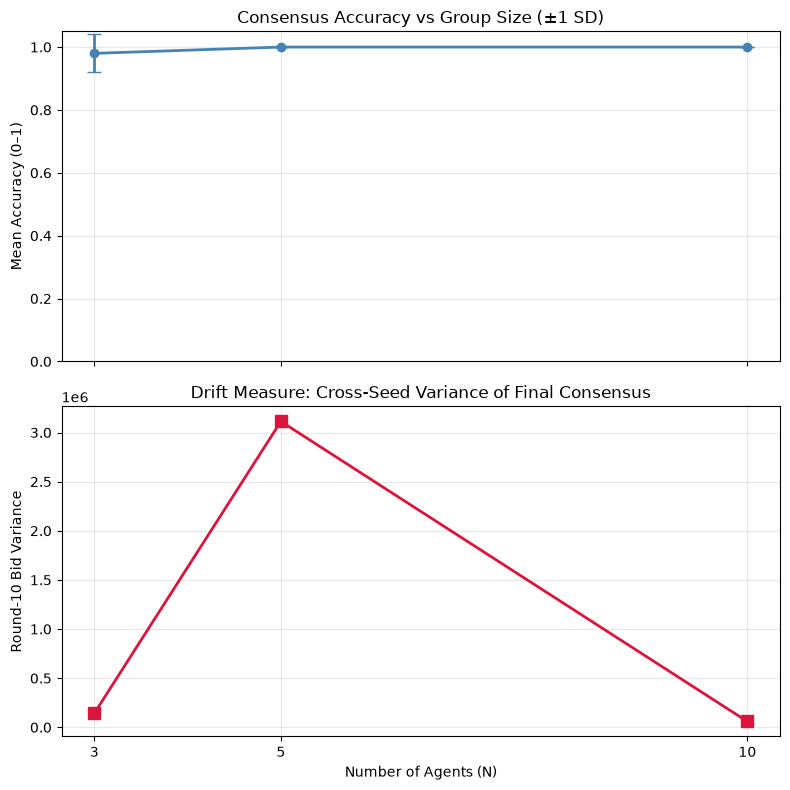

Saved drift_selection_plot.png
Drift-selection crossover N = 5
Saved readme.md


In [20]:
# Cell 17: Plot and save + write readme

Ns = summary_df["N"].tolist()
mean_acc = summary_df["mean_accuracy"].tolist()
std_acc = summary_df["std_accuracy"].tolist()
bid_var = summary_df["bid_variance_R10"].tolist()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Accuracy plot
ax1.errorbar(
    Ns,
    mean_acc,
    yerr=std_acc,
    fmt="-o",
    capsize=5,
    color="steelblue",
    lw=2
)
ax1.set_ylabel("Mean Accuracy (0–1)")
ax1.set_ylim(0, 1.05)
ax1.set_title("Consensus Accuracy vs Group Size (±1 SD)")
ax1.grid(alpha=0.3)

# Drift plot
ax2.plot(
    Ns,
    bid_var,
    "-s",
    color="crimson",
    lw=2,
    markersize=9
)
ax2.set_xlabel("Number of Agents (N)")
ax2.set_ylabel("Round-10 Bid Variance")
ax2.set_title("Drift Measure: Cross-Seed Variance of Final Consensus")
ax2.set_xticks(Ns)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("drift_selection_plot.png", dpi=150)
plt.show()

print("Saved drift_selection_plot.png")
print(f"Drift-selection crossover N = {crossover_N}")

# ----------------------------------------------------
# Generate README
# ----------------------------------------------------

readme = f"""# Week 5 — Multi-Agent Collective Intelligence

## Setup

- Model: `{MODEL}` via Groq
- N ∈ {Ns}, 10 seeds each, 10 rounds, 3 gossip sub-rounds
- Fixed ring topology per game

## Results

| N | Mean Accuracy | Std Accuracy | Round-10 Bid Variance |
|---|---:|---:|---:|
"""

for N in Ns:
    row = summary_df[summary_df["N"] == N].iloc[0]
    readme += (
        f"| {N} | "
        f"{row['mean_accuracy']:.3f} | "
        f"{row['std_accuracy']:.3f} | "
        f"{row['bid_variance_R10']:.2f} |\n"
    )

readme += f"""

**Drift-selection crossover N = {crossover_N}**

## Analysis

At N = {crossover_N}, the round-10 consensus variance reaches its maximum.
The gossip chain amplifies early information faster than agents can reason,
producing memetic drift.

Below this crossover, reasoning dominates consensus formation (selection).
At or above this crossover, outcomes become increasingly dependent on
which agent happened to speak first with high confidence.
"""

# Save using UTF-8 encoding
with open("readme.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("Saved readme.md")